In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df =pd.read_csv("marketing_AB.csv")
print(df)

        Unnamed: 0  user id test group  converted  total ads most ads day  \
0                0  1069124         ad      False        130       Monday   
1                1  1119715         ad      False         93      Tuesday   
2                2  1144181         ad      False         21      Tuesday   
3                3  1435133         ad      False        355      Tuesday   
4                4  1015700         ad      False        276       Friday   
...            ...      ...        ...        ...        ...          ...   
588096      588096  1278437         ad      False          1      Tuesday   
588097      588097  1327975         ad      False          1      Tuesday   
588098      588098  1038442         ad      False          3      Tuesday   
588099      588099  1496395         ad      False          1      Tuesday   
588100      588100  1237779         ad      False          1      Tuesday   

        most ads hour  
0                  20  
1                  22  
2  

In [4]:
df.head(5)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [5]:
df.shape

(588101, 7)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB


In [7]:
df.describe(include="all")

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
count,588101.000000,5.881010e+05,588101,588101,588101.000000,588101,588101.000000
unique,NaN,NaN,2,2,NaN,7,NaN
top,NaN,NaN,ad,False,NaN,Friday,NaN
freq,NaN,NaN,564577,573258,NaN,92608,NaN
mean,294050.000000,1.310692e+06,NaN,NaN,24.820876,NaN,14.469061
std,169770.279668,2.022260e+05,NaN,NaN,43.715181,NaN,4.834634
min,0.000000,9.000000e+05,NaN,NaN,1.000000,NaN,0.000000
25%,147025.000000,1.143190e+06,NaN,NaN,4.000000,NaN,11.000000
50%,294050.000000,1.313725e+06,NaN,NaN,13.000000,NaN,14.000000
75%,441075.000000,1.484088e+06,NaN,NaN,27.000000,NaN,18.000000


In [8]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [9]:
df["test group"].value_counts()


test group
ad     564577
psa     23524
Name: count, dtype: int64

In [10]:
df["converted"].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

In [11]:
df["user id"].nunique()  #unique users

588101

In [12]:
df = df.drop(columns=["Unnamed: 0"])

In [13]:
df.head()


,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [14]:
df.shape

(588101, 6)

In [15]:
df ["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [16]:
df ["converted"].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

In [17]:
df.groupby("test group")["converted"].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [18]:
#what percentage of the ads group or the PSA group converted?

conversion_by_group = df.groupby ("test group")["converted"].mean() *100
print(conversion_by_group)

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64


Absolute difference between the two advertisement modes

In [19]:
ad_rate = df[df["test group"] == "ad"]["converted"].mean()
psa_rate = df[df["test group"] == "psa"]["converted"].mean()

absolute_difference = abs(ad_rate - psa_rate)

print(f"The Absolute difference is {absolute_difference:.4f}")

The Absolute difference is 0.0077


In [20]:
#relative lift to the baseline (PSA) group

relative_lift = (ad_rate - psa_rate) / psa_rate

print(f"The Relative lift is {relative_lift:.2%}")

The Relative lift is 43.09%


Visualise the difference in conversion

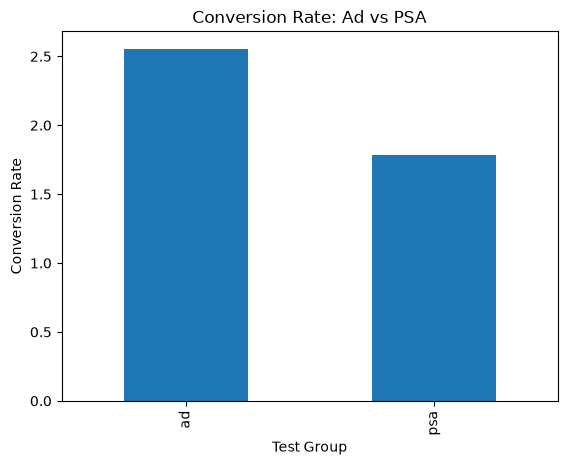

In [21]:
conversion_by_group.plot(kind="bar")

plt.title("Conversion Rate: Ad vs PSA")
plt.ylabel("Conversion Rate")
plt.xlabel("Test Group")
plt.show()

A/B Testing: Null Hypothesis(H0) says there is no difference in conversion rates between people who saw the ad and people who saw the PSA. 

Alternative hypothesis(H1) says there is a difference in conversion rates between people who saw the ad and people who saw the PSA.  

In [22]:
from statsmodels.stats.proportion import proportions_ztest  


In [23]:
conversions = df.groupby("test group")["converted"].sum()

print(conversions)

test group
ad     14423
psa      420
Name: converted, dtype: int64


In [24]:
#Number of observations in each group

group_sizes = df["test group"].value_counts()
print(group_sizes)

test group
ad     564577
psa     23524
Name: count, dtype: int64


In [ ]:
count = [
    conversions["ad"],
    conversions["psa"]
]

Nobs = [
    group_sizes["ad"],
    group_sizes["psa"]
]

z_stat, p_value = proportions_ztest(count,  Nobs)

print("The Z-statistic is:", z_stat)
print("The P-value is:", p_value)

The Z-statistic is: 7.3700781265454145
The P-value is: 1.7052807161559727e-13


In [27]:
#Using a 5% significance level we would make a decision

alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a statistically significant difference between the two groups.")
else:
    print("Fail to reject H0: There is not enough evidence of a difference between the two groups.")

Reject H0: There is a statistically significant difference between the two groups.


In [29]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    conversions["ad"],
    group_sizes["ad"],
    conversions["psa"],
    group_sizes["psa"],
    method="wald"
)

print("95% CI:", ci_low, ci_high)

95% CI: 0.005950932431611005 0.00943397395279203


Does the amount of advertising exposure appear to be related to conversion?

In [30]:
#Compare people who converted versus those that did not

df.groupby("converted")["total ads"].describe()

,count,mean,std,min,25%,50%,75%,max
converted,,,,,,,,
False,573258.0,23.291495,40.863176,1.0,4.0,13.0,26.0,2065.0
True,14843.0,83.887759,87.455498,1.0,35.0,64.0,103.0,1778.0


People who converted saw an average of 84 ads and non-converters 23 ads. This therefore shows a that converters were exposed to more ads on average than non-converters. However this is an association rather than evidence that greater ad exposure caused conversion. 

In [31]:
#Group the numbers

df["ad_exposure_group"] = pd.cut(
    df["total ads"],
    bins=[0, 5, 10, 20, 50, 100, float("inf")],
    labels=["1-5", "6-10", "11-20", "21-50", "51-100", "100+"]
)

In [32]:
exposure_conversion = (
    df.groupby("ad_exposure_group", observed=True)["converted"]
    .mean() * 100
)

print(exposure_conversion)

ad_exposure_group
1-5        0.252498
6-10       0.493056
11-20      0.839321
21-50      2.885851
51-100    11.395157
100+      16.905134
Name: converted, dtype: float64


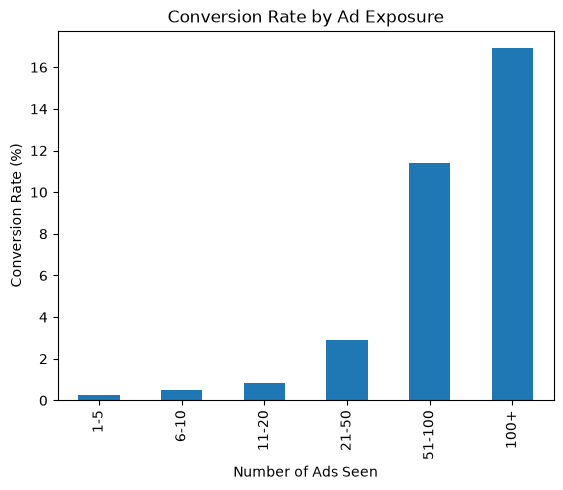

In [34]:
#How does conversion vary as ad exposure increases? (Visually)

exposure_conversion.plot(kind="bar")

plt.title("Conversion Rate by Ad Exposure")
plt.xlabel("Number of Ads Seen")
plt.ylabel("Conversion Rate (%)")
plt.show()

In [35]:
#To verify by the day the audience saw the ads

conversion_by_day = (
    df.groupby("most ads day")["converted"]
    .mean()
    .sort_values(ascending=False) * 100
)

print(conversion_by_day)

most ads day
Monday       3.281155
Tuesday      2.984034
Wednesday    2.494191
Sunday       2.447565
Friday       2.221190
Thursday     2.157094
Saturday     2.105070
Name: converted, dtype: float64


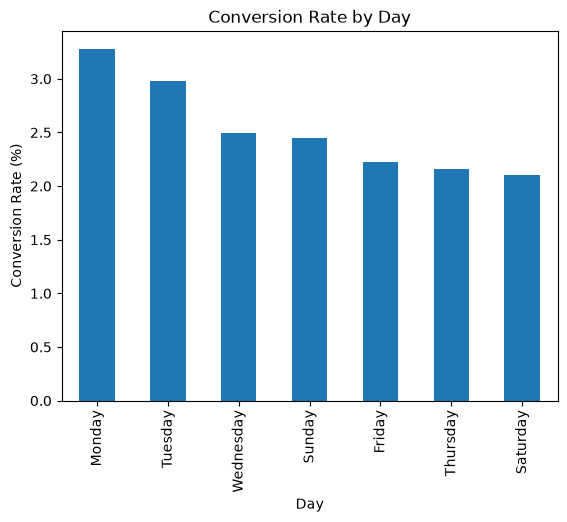

In [36]:
#Visualise

conversion_by_day.plot(kind="bar")

plt.title("Conversion Rate by Day")
plt.xlabel("Day")
plt.ylabel("Conversion Rate (%)")
plt.show()


In [37]:
#To verify by the hour the ads was been seen

conversion_by_hour = (
    df.groupby("most ads hour")["converted"]
    .mean() * 100
)

print(conversion_by_hour)

most ads hour
0     1.842486
1     1.291129
2     0.731296
3     1.045166
4     1.523546
5     2.091503
6     2.224371
7     1.811085
8     1.951552
9     1.919107
10    2.152084
11    2.211643
12    2.382765
13    2.467737
14    2.806257
15    2.965334
16    3.077169
17    2.820967
18    2.737988
19    2.671982
20    2.980327
21    2.892314
22    2.610472
23    2.266191
Name: converted, dtype: float64


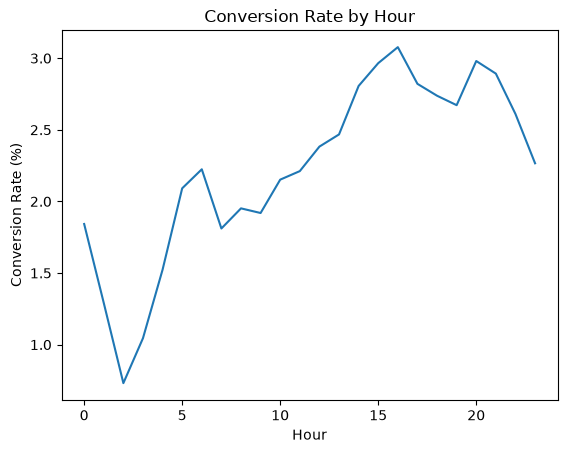

In [38]:
# Visualise

conversion_by_hour.plot()

plt.title("Conversion Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Conversion Rate (%)")
plt.show()

conversion varied across differnt advertising hours

In [39]:
df.groupby("test group")["total ads"].describe()

,count,mean,std,min,25%,50%,75%,max
test group,,,,,,,,
ad,564577.0,24.823365,43.750456,1.0,4.0,13.0,27.0,2065.0
psa,23524.0,24.761138,42.860720,1.0,4.0,12.0,26.0,907.0


In [40]:
exposure_by_group = df.groupby("test group")["total ads"].agg(
    ["mean", "median", "max"]
)

print(exposure_by_group)

                 mean  median   max
test group                         
ad          24.823365    13.0  2065
psa         24.761138    12.0   907


The A/B test indicates that the advertising campaign outperformed the PSA. The ad group recorded a conversion rate of approximately 2.55%, compared with 1.79% for the PSA group, representing an absolute improvement of approximately 0.77 percentage points and a 43.1% relative lift.

The difference was statistically significant at the 5% significance level (p < 0.05), so the null hypothesis of no difference in conversion rates is rejected. The 95% confidence interval for the difference in conversion rates is approximately 0.60 to 0.94 percentage points, providing further evidence that the ad campaign generated a meaningful improvement in conversion.

Ad exposure was also associated with conversion. Users who converted were exposed to substantially more ads on average than users who did not convert. Conversion rates also varied across levels of ad exposure, suggesting that exposure may be an important factor in the customer journey. However, this analysis demonstrates an association rather than causation; higher exposure may partly reflect users who were already more engaged or likely to convert.

Conversion rates also varied by the day and hour at which users saw the greatest number of ads. Monday had the highest observed conversion rate, while Saturday had the lowest, suggesting that timing may influence campaign performance. However, these differences should be treated as directional findings rather than definitive evidence of the best advertising time.